In [1]:
from google.colab import drive
drive.mount('/content/drive')
# !mkdir -p /content/drive/MyDrive/aiffel/word_embedding
import os
os.chdir('/content/drive/MyDrive/aiffel/word_embedding')

Mounted at /content/drive


In [3]:
!pip install konlpy gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 24.3 MB/s eta 0:00:00


In [4]:
import konlpy
import gensim
import sklearn
import seaborn

print(konlpy.__version__)
print(gensim.__version__)
print(sklearn.__version__)
print(seaborn.__version__)

0.6.0
4.4.0
1.6.1
0.13.2


In [5]:
import os

# 현재 위치('./')에서 'synopsis_'로 시작하는 모든 .txt 파일 찾기
files = os.listdir('./')
synopsis_files = [file for file in files if file.startswith('synopsis_') and file.endswith('.txt')]

print(f"찾아낸 파일 개수: {len(synopsis_files)}개")
print("파일 목록:")
for file in sorted(synopsis_files):
    print(" -", file)

찾아낸 파일 개수: 23개
파일 목록:
 - synopsis_SF.txt
 - synopsis_action.txt
 - synopsis_adult.txt
 - synopsis_adventure.txt
 - synopsis_animation.txt
 - synopsis_art.txt
 - synopsis_comedy.txt
 - synopsis_crime.txt
 - synopsis_documentary.txt
 - synopsis_drama.txt
 - synopsis_etc.txt
 - synopsis_family.txt
 - synopsis_fantasy.txt
 - synopsis_gen.txt
 - synopsis_historical.txt
 - synopsis_horror.txt
 - synopsis_musical.txt
 - synopsis_mystery.txt
 - synopsis_romance.txt
 - synopsis_show.txt
 - synopsis_thriller.txt
 - synopsis_war.txt
 - synopsis_western.txt


In [6]:
from konlpy.tag import Okt
from tqdm.notebook import tqdm

okt = Okt()

# 1. 파일 목록 가져오기
files = os.listdir('./')
synopsis_files = [file for file in files if file.startswith('synopsis_') and file.endswith('.txt')]

# 장르별 명사 텍스트를 담을 딕셔너리
genre_nouns = {}

# 2. 23개 파일 반복문 돌며 명사 추출
for file_name in synopsis_files:
    # 예: 'synopsis_SF.txt' -> 'SF' 장르 이름만 추출
    genre_name = file_name.replace('synopsis_', '').replace('.txt', '')

    # 각 파일의 줄 수 세기 (진행바 표시용)
    with open(file_name, 'r', encoding='utf-8') as f:
        total_lines = sum(1 for line in f)

    result = []
    # 파일 읽고 명사 추출
    with open(file_name, 'r', encoding='utf-8') as f:
        for line in tqdm(f, total=total_lines, desc=f"[{genre_name}] 분석 중"):
            tokenlist = okt.pos(line, stem=True, norm=True)
            for word in tokenlist:
                if word[1] in ["Noun"]:  # 명사만 추출
                    result.append(word[0])

    # 공백으로 이어붙인 하나의 큰 문자열로 저장
    genre_nouns[genre_name] = ' '.join(result)

print("\n전체 23개 파일 형태소 분석 완료!")

[art] 분석 중:   0%|          | 0/14435 [00:00<?, ?it/s]

[gen] 분석 중:   0%|          | 0/48116 [00:00<?, ?it/s]

[horror] 분석 중:   0%|          | 0/3088 [00:00<?, ?it/s]

[musical] 분석 중:   0%|          | 0/170 [00:00<?, ?it/s]

[thriller] 분석 중:   0%|          | 0/2265 [00:00<?, ?it/s]

...

[action] 분석 중:   0%|          | 0/5860 [00:00<?, ?it/s]

[drama] 분석 중:   0%|          | 0/19229 [00:00<?, ?it/s]

[adult] 분석 중:   0%|          | 0/1647 [00:00<?, ?it/s]

[family] 분석 중:   0%|          | 0/422 [00:00<?, ?it/s]


전체 23개 파일 형태소 분석 완료!


23개의 텍스트를 하나하나 형태서 분석을 하면 코드도 길어지고 시간도 오래걸리니  
for문을 사용하여 한번에 분석합니다.

In [7]:
from gensim.models import Word2Vec

# genre_nouns에 저장된 명사 문장들을 Word2Vec 학습용(리스트의 리스트)으로 변환
sentences = [doc.split() for doc in genre_nouns.values()]

# Word2Vec 모델 학습
model = Word2Vec(sentences=sentences, vector_size=100, window=5, min_count=1, sg=0)

print("Word2Vec 모델 학습 완료!")

Word2Vec 모델 학습 완료!


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. 전체 장르 텍스트 리스트 및 장르명 리스트 작성
genre_names = list(genre_nouns.keys())
corpus = [genre_nouns[name] for name in genre_names]

# 2. TF-IDF 계산 (상위 500개 단어 대상)
vectorizer = TfidfVectorizer(max_features=500)
tfidf_matrix = vectorizer.fit_transform(corpus)
words = vectorizer.get_feature_names_out()

# 3. 각 장르별 TF-IDF 상위 100개 단어 추출 함수
def get_top_words(genre_name, top_n=100):
    idx = genre_names.index(genre_name)
    row = tfidf_matrix[idx].toarray().squeeze()
    top_indices = row.argsort()[::-1][:top_n]
    return [words[i] for i in top_indices if row[i] > 0]

# 4. Target 단어 세트 추출 (art vs gen 차집합 활용)
n = 15
art_top = get_top_words('art')
gen_top = get_top_words('gen')

# art에만 있고 gen에는 없으며, Word2Vec 모델(model.wv)에 존재하는 단어 추출
target_art = [w for w in art_top if w not in gen_top and w in model.wv][:n]
# gen에만 있고 art에는 없으며, Word2Vec 모델(model.wv)에 존재하는 단어 추출
target_gen = [w for w in gen_top if w not in art_top and w in model.wv][:n]

# 5. Attribute 단어 세트 추출 (나머지 21개 장르)
attributes = {}
attribute_genres = [g for g in genre_names if g not in ['art', 'gen']]

for g in attribute_genres:
    top_w = get_top_words(g)
    # Word2Vec 단어장에 있는 단어만 상위 15개 추출
    valid_words = [w for w in top_w if w in model.wv][:n]
    attributes[g] = valid_words

print(f"Target Art (예술 축 단어 {len(target_art)}개):", target_art)
print(f"Target Gen (일반 축 단어 {len(target_gen)}개):", target_gen)
print(f"\nAttribute 장르 개수: {len(attributes)}개 장르 준비 완료!")

Target Art (예술 축 단어 15개): ['음악', '위기', '최고', '지금', '결심', '운명', '여인', '충격', '이름', '이후', '준비', '감정', '그린', '상처', '만난']
Target Gen (일반 축 단어 15개): ['서울', '애니메이션', '작품', '여성', '섹스', '부문', '연출', '다큐멘터리', '가지', '대해', '주인공', '사회', '회사', '다큐', '존재']

Attribute 장르 개수: 21개 장르 준비 완료!


In [9]:
# 21개 장르별 상위 15개 단어장 출력
print("=== 21개 장르별 Attribute 단어장 (상위 15개) ===")
for genre, words in attributes.items():
    print(f"[{genre}] ({len(words)}개)")
    print(", ".join(words))
    print("-" * 50)

=== 21개 장르별 Attribute 단어장 (상위 15개) ===
[horror] (15개)
시작, 위해, 사람, 자신, 친구, 그녀, 사건, 공포, 발견, 죽음, 마을, 가족, 남자, 좀비, 영화
--------------------------------------------------
[musical] (15개)
사랑, 그녀, 음악, 영화, 자신, 영화제, 시작, 위해, 최고, 애니, 공연, 사람, 도시, 이야기, 노래
--------------------------------------------------
[thriller] (15개)
자신, 그녀, 사건, 시작, 위해, 사람, 살인, 남자, 발견, 아내, 경찰, 친구, 모든, 사실, 가족
--------------------------------------------------
[romance] (15개)
그녀, 사랑, 자신, 시작, 남편, 남자, 여자, 사람, 친구, 위해, 섹스, 마음, 결혼, 서로, 아내
--------------------------------------------------
[comedy] (15개)
그녀, 자신, 시작, 위해, 사랑, 사람, 친구, 영화, 남자, 여자, 영화제, 가족, 과연, 마을, 사건
--------------------------------------------------
[fantasy] (15개)
자신, 그녀, 시작, 위해, 사람, 사랑, 영화제, 이야기, 영화, 소녀, 남자, 인간, 세상, 마을, 세계
--------------------------------------------------
[historical] (15개)
위해, 시작, 사랑, 자신, 그녀, 최고, 사람, 운명, 전쟁, 사건, 역사, 마음, 모든, 이야기, 소리
--------------------------------------------------
[crime] (15개)
사건, 위해, 자신, 경찰, 시작, 그녀, 범죄, 조직, 살인, 사람, 마약, 형사, 남자, 모든, 살

원래는 20개를 하려고 했지만 예제에서도 15개를 하였고 제미나이에게도 물어봤지만    
20개를 해도 상관은 없지만 지금처럼 데이터가 많지 않다면 단어장에 장르와    
관련없는 데이터가 들어올 수도 있다고 하여 예제와 같이 15개로 했습니다.  

In [23]:
print(model.wv.most_similar('사랑', topn=5))
# 사랑을 검색하여 유사도 테스트를 해봅니다.

[('남자', 0.9991174340248108), ('서로', 0.9986890554428101), ('앞', 0.9983130097389221), ('둘', 0.9981958866119385), ('자신', 0.9979231953620911)]


In [18]:
!sudo apt-get install -y fonts-nanum
!fc-cache -fv                                 # 한글이 깨지는 문제 나눔 폰트 다운

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 1 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (5,996 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118419 files and direc

밑에 시각화를 하는 과정에서 폰트가 깨져서 [] 으로 보이는 현상이 있어서 한글 폰트를 다운 후 지정해줍니다.

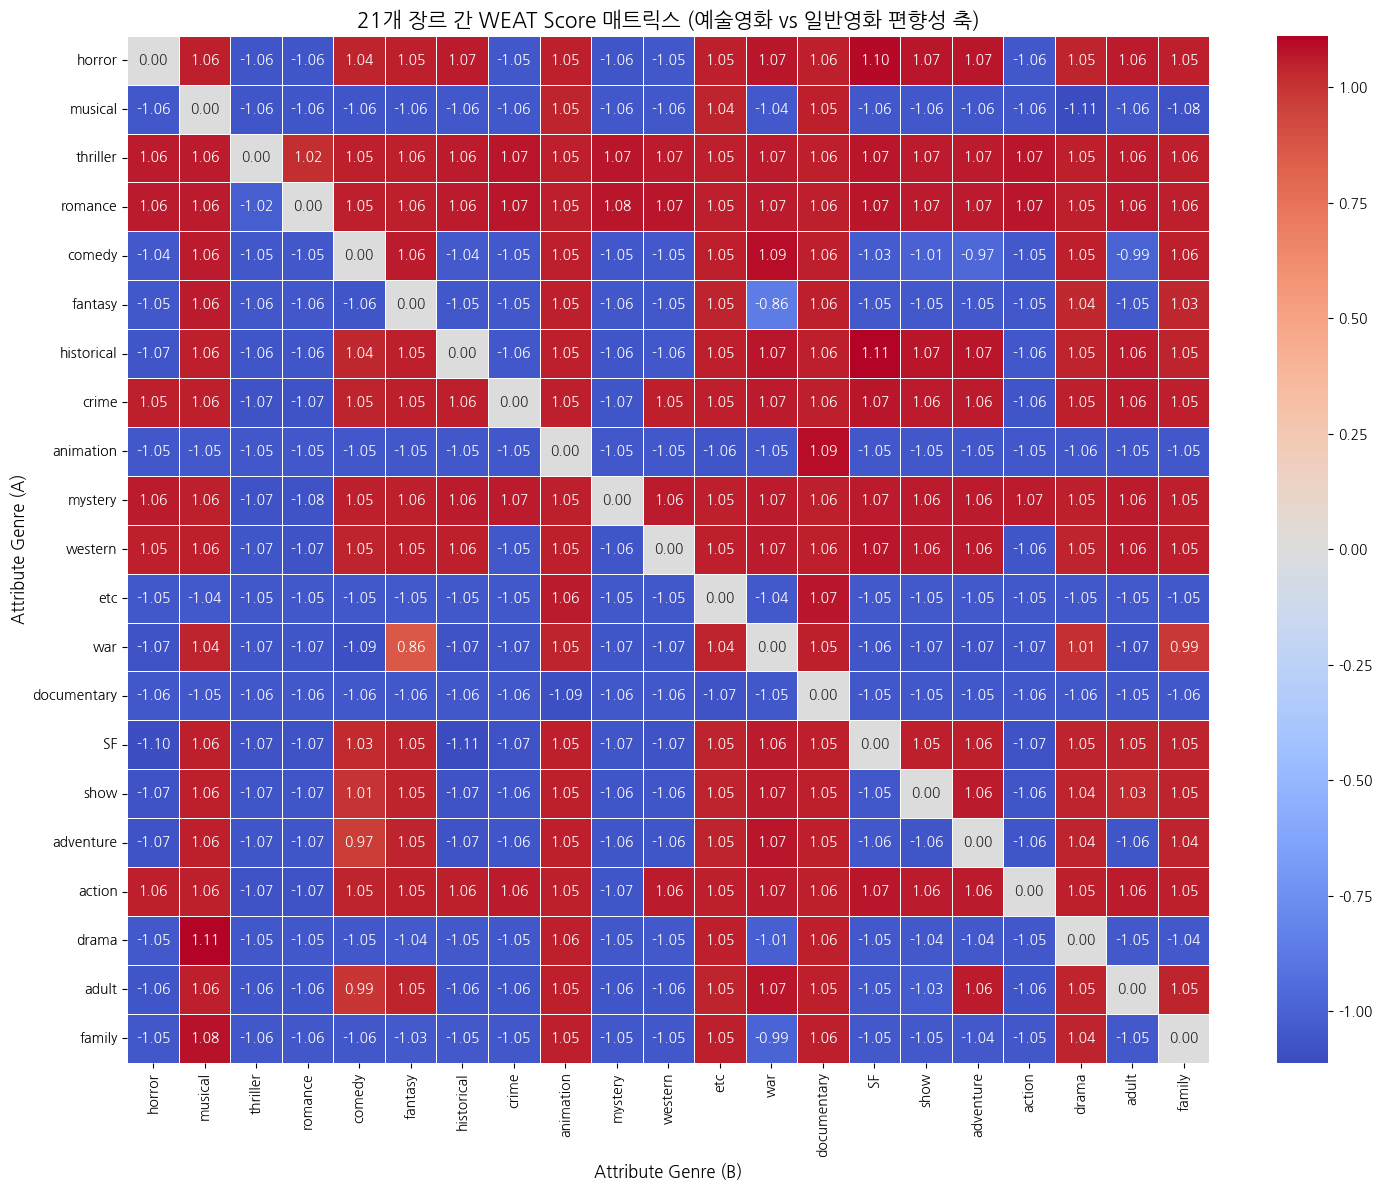

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from numpy import dot
from numpy.linalg import norm
import matplotlib.font_manager as fm

# 한글 폰트 경로 직접 지정 및 캐시 등록
# Matplotlib 폰트 매니저에 나눔고딕 등록
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
plt.rc('font', family=font_prop.get_name())
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 2. 코사인 유사도 및 WEAT 관련 함수 정의
def cos_sim(A, B):
    return dot(A, B) / (norm(A) * norm(B))

def s(w, A, B):
    c_A = np.mean([cos_sim(w, a) for a in A], axis=0)
    c_B = np.mean([cos_sim(w, b) for b in B], axis=0)
    return c_A - c_B

def weat_score(X, Y, A, B):
    s_X = [s(x, A, B) for x in X]
    s_Y = [s(y, A, B) for y in Y]

    mean_X = np.mean(s_X)
    mean_Y = np.mean(s_Y)

    std_dev = np.std(np.concatenate([s_X, s_Y]))

    if std_dev == 0:
        return 0
    return (mean_X - mean_Y) / std_dev

# 3. Target 축 세트 (X: 예술, Y: 일반)
X = np.array([model.wv[word] for word in target_art])
Y = np.array([model.wv[word] for word in target_gen])

# 4. 21개 장르 매트릭스 전체 순회 계산
genre_name = list(attributes.keys())
matrix = np.zeros((len(genre_name), len(genre_name)))

for i in range(len(genre_name)):
    for j in range(len(genre_name)):
        if i != j:
            A = np.array([model.wv[word] for word in attributes[genre_name[i]]])
            B = np.array([model.wv[word] for word in attributes[genre_name[j]]])
            matrix[i][j] = weat_score(X, Y, A, B)

# 5. 히트맵 시각화
df_matrix = pd.DataFrame(matrix, index=genre_name, columns=genre_name)

plt.figure(figsize=(15, 12))

sns.heatmap(df_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=.5)
plt.title('21개 장르 간 WEAT Score 매트릭스 (예술영화 vs 일반영화 편향성 축)', fontsize=15)
plt.xlabel('Attribute Genre (B)', fontsize=12)
plt.ylabel('Attribute Genre (A)', fontsize=12)
plt.tight_layout()  # 제목 및 축 레이아웃 자동 정돈
plt.show()

시각화가 정말 사기입니다. 확실히 데이터 텍스트로 보는 것과 느낌이 전혀 다릅니다.  
처음에 예제를 따라갔을 땐 정말 코드 길어보이고 오래 걸릴 것 같았지만  
막상 해보니 for문으로 돌려서 한번에 가져오고 한번에 단어장도 추출해서 생각보다 짧았습니다.  
예제를 따라하며 결과를 봤을 때는 크게 별 느낌이 없었지만  
마지막에 시각화까지 하고나니 받는 느낌이 전혀 달랐고 시각화가 역시 중요하구나를 다시 한번 알고 갑니다.